# Likelihood

This notebook plots the likelihood curves for some runs


---

In [5]:

"""A utils module used for loading data and parameters for the parameter estimation examples."""
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import glob
import json
import pandas as pd

from argus import data_loader
from argus import gravitational_waves


def _get_processed_residuals(directory):
    """Get the processed residuals from the data."""

    # Get all .par and .tim files in the directory
    par_files = sorted(glob.glob(directory + "*.par"))
    tim_files = sorted(glob.glob(directory + "*.tim"))

    assert len(par_files) == len(tim_files), "Mismatch between .par and .tim file counts."

    #Exclude PR J1640+2224 as it has an exponent which is to small for the OU process to be valid
    par_files = [f for f in par_files if "J1640" not in f]
    tim_files = [f for f in tim_files if "J1640" not in f]



    # Get the data
    print(f"Getting the data. Loading {len(par_files)} pulsars from {directory}")
    pulsar_residuals, pulsar_metadata, pulsar_design_matrices,P_eps_matrices = (
        data_loader.LoadWidebandPulsarData.read_multiple_par_tim(par_files, tim_files)
    )

    # Get the separation angles and compute HD correlation
    ra = pulsar_metadata["RA"].to_numpy(dtype=float)
    dec = pulsar_metadata["DEC"].to_numpy(dtype=float)
    angular_separation_matrix = gravitational_waves.pairwise_angular_separation(ra, dec)
    hd_correlation_matrix = gravitational_waves.hellings_downs(angular_separation_matrix)

    # Post-process the residuals    
    processed_pulsar_residuals = data_loader.LoadWidebandPulsarData.process_pulsar_residuals_by_epoch(pulsar_residuals)

    return processed_pulsar_residuals, pulsar_metadata, pulsar_design_matrices,P_eps_matrices,hd_correlation_matrix

def get_efac_equad_injections():

    # Load the noise parameters from the json file
    with open("../data/IPTA_MockDataChallenge2/group1_psr_noise.json", "r") as f:
        noise_params = json.load(f)

    # Extract EFAC and EQUAD values for each pulsar
    efac_values = []
    equad_values = []

    for psr in noise_params:

        if  "J1640" not in psr:
            efac_values.append(noise_params[psr]["efac"])
            equad_values.append(10**noise_params[psr]["equad"]) # Convert from log10 to linear

    # Convert to JAX arrays
    efac_array = jnp.array(efac_values)
    equad_array = jnp.array(equad_values)


    return efac_array, equad_array

def get_psr_noise_injections():

    df = pd.read_pickle('../notebooks/approximate_spin_injections.pkl')
    condition = df['psr'] != 'J1640+2224'



    # 2. Use the condition to select rows and create a new DataFrame
    df_filtered = df[condition]


    sigma_p_injected = df_filtered['optimal_sigma'].values
    gamma_p_injected = df_filtered['optimal_gamma'].values

    return jnp.array(sigma_p_injected), jnp.array(gamma_p_injected)






In [6]:

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax.scipy.linalg import block_diag
from jax import random


import pandas as pd
import numpy as np 
from flax import struct
from datetime import datetime


from argus import models
from argus import jax_kalman_filter


#NumPyro
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC,SA,NUTS


#Arviz
import arviz as az


@struct.dataclass
class Parameters:

    """Define a struct to store the parameters of the Kalman filter model"""
    
    #GW parameters
    γa: float  # s⁻¹
    ha: float  # GWB amplitude

    #Pulsar parameters for the OU process
    γp: jnp.ndarray  # Pulsar-specific gamma values
    σp: jnp.ndarray  # Pulsar-specific sigma values 

    #Measurement noise parameters
    EFAC: jnp.ndarray  # Error factors
    EQUAD: jnp.ndarray # Extra quadrature noise




def get_likelihood_curve():

    #Get the data
    data_path = "../data/IPTA_MockDataChallenge2/dataset_2b/" 
    processed_pulsar_residuals, pulsar_metadata, pulsar_design_matrices,P_eps_matrices,hd_correlation_matrix = _get_processed_residuals(data_path)

    #Get efac and equad
    efac_array, equad_array = get_efac_equad_injections()
    assert len(efac_array) == len(equad_array) == len(pulsar_metadata)

    #Get psr noise 
    sigma_p_injected, gamma_p_injected = get_psr_noise_injections()
    assert len(sigma_p_injected) == len(gamma_p_injected) == len(pulsar_metadata)


    #Calculate P0 based on the maximum value of the design matrix, and a delta tolerance
    model = models.StochasticGWBackgroundModel(pulsar_metadata, hd_correlation_matrix, pulsar_design_matrices)

    alpha = 1.0 #scale slightly 
    P0 = alpha*block_diag(*P_eps_matrices)


    KF = jax_kalman_filter.JaxKalmanFilter(
        model=model, 
        observations=processed_pulsar_residuals, 
        Peps=P0
    )




    γa = 1e-9 
    ha = 10**(-15.51)#1e-15

    #Set the parameters
    params = Parameters(
        #GW parameters
        γa=γa,
        ha=ha,

        #Spin parameters
        γp=gamma_p_injected,
        σp=sigma_p_injected,

        #Measurement noise parameters
        EFAC=efac_array,
        EQUAD=equad_array
    )

    print("First call to get_likelihood. Just for precompilation")
    ll = KF.get_likelihood(params) 
    ll.block_until_ready()
    print("Likelihood: ",ll)



    print("Starting the loop")

    psr_idx = 10
    sigma_p_idx = sigma_p_injected[psr_idx]
    print("sigma_p_idx: ",sigma_p_idx)
    sigma_p_lower = 1e-17
    sigma_p_upper = 1e-15

    xvals = np.logspace(np.log10(sigma_p_lower),np.log10(sigma_p_upper),100)
    yvals = np.zeros_like(xvals)
    for i,s in enumerate(xvals):


        s_array = sigma_p_injected.at[psr_idx].set(s)
        #Set the parameters
        params = Parameters(
            #GW parameters
            γa=γa,
            ha=ha,

            #Spin parameters
            γp=gamma_p_injected,
            σp=s_array,

            #Measurement noise parameters
            EFAC=efac_array*20,
            EQUAD=equad_array
        )

 
        ll = KF.get_likelihood(params) 
        yvals[i] = ll

    return xvals, yvals






In [7]:
xvals,yvals = get_likelihood_curve()

Getting the data. Loading 32 pulsars from ../data/IPTA_MockDataChallenge2/dataset_2b/
[tempo2Util.C:396] Warning: [TIM1] Please place MODE flags in the parameter file 
[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0030+0451, F0: 205.53069593846152, # TOAs: 183
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0034-0534, F0: 532.7134293952242, # TOAs: 183
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0218+4232, F0: 430.46105454575843, # TOAs: 183
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0437-4715, F0: 173.6879457375193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0613-0200, F0: 326.60056202349193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0621+1002 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0621+1002, F0: 34.65740662142043, # TOAs: 183
[preProcess.C:158] Warning: PSR J0711-6830 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0711-6830, F0: 182.1172346472276, # TOAs: 183
[preProcess.C:158] Warning: PSR J0751+1807 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0751+1807, F0: 287.4578539950941, # TOAs: 183
[preProcess.C:158] Warning: PSR J0900-3144 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0900-3144, F0: 90.0118419193632, # TOAs: 183
[preProcess.C:158] Warning: PSR J1012+5307 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1012+5307, F0: 190.26783444155498, # TOAs: 183
[preProcess.C:158] Warning: PSR J1022+1001 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1022+1001, F0: 60.779447956696714, # TOAs: 183
[preProcess.C:158] Warning: PSR J1024-0719 uses DM2+ but does not define DM_SERIES.

PSR: J1603-7202, F0: 67.37658112877924, # TOAs: 183
[preProcess.C:158] Warning: PSR J1614-2230 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1614-2230, F0: 317.37893706872126, # TOAs: 183
[preProcess.C:158] Warning: PSR J1643-1224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1643-1224, F0: 216.37333714263485, # TOAs: 183
[preProcess.C:158] Warning: PSR J1713+0747 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1713+0747, F0: 218.81184041715784, # TOAs: 183
[preProcess.C:158] Warning: PSR J1730-2304 uses DM2+ but does not define DM_SERIE

PSR: J1939+2134, F0: 641.9282245822469, # TOAs: 183
[preProcess.C:158] Warning: PSR J1944+0907 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J1944+0907, F0: 192.85651792018598, # TOAs: 183
[preProcess.C:158] Warning: PSR J2010-1323 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2010-1323, F0: 191.45090909263828, # TOAs: 183
[preProcess.C:158] Warning: PSR J2124-3358 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2124-3358, F0: 202.7938937460303, # TOAs: 183
[preProcess.C:158] Warning: PSR J2129-5721 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2129-5721, F0: 268.3592272938787, # TOAs: 183
[preProcess.C:158] Warning: PSR J2145-0750 uses DM2+ but does not define DM_SERIES

PSR: J2145-0750, F0: 62.29588783738885, # TOAs: 183
[preProcess.C:158] Warning: PSR J2229+2643 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2229+2643, F0: 335.81620819685526, # TOAs: 183
[preProcess.C:158] Warning: PSR J2317+1439 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2317+1439, F0: 290.2546036648635, # TOAs: 183
The number of pulsars is: 32
The frequencies are: [205.53069594 532.7134294  430.46105455 173.68794574 326.60056202
  34.65740662 182.11723465 287.457854    90.01184192 190.26783444
  60.77944796 193.71568345 133.79314954 125.20024324 277.93770699
  67.37658113 317.37893707 216.37333714 218.81184042 123.11028715
 245.42611969 186.49407838 339.31568722 130.78951412 641.

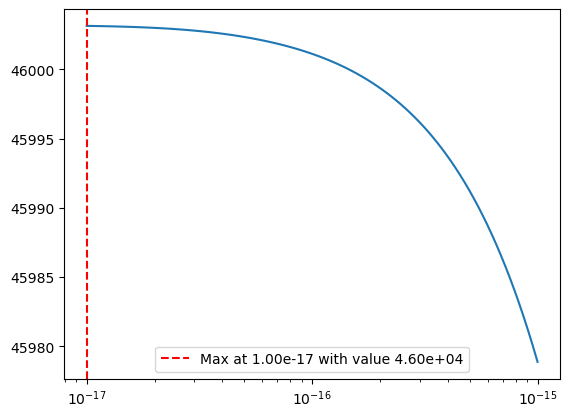

In [8]:
import matplotlib.pyplot as plt
plt.plot(xvals, yvals)
max_idx = np.argmax(yvals)
max_y = yvals[max_idx]
plt.axvline(x=xvals[max_idx], color='r', linestyle='--', label=f'Max at {xvals[max_idx]:.2e} with value {max_y:.2e}')
plt.legend()
plt.xscale('log')

# Likelihood curve_for_ha

In [9]:
def get_likelihood_curve_for_ha():

    #Get the data
    data_path = "../data/IPTA_MockDataChallenge2/dataset_2b/" 
    processed_pulsar_residuals, pulsar_metadata, pulsar_design_matrices,P_eps_matrices,hd_correlation_matrix = _get_processed_residuals(data_path)

    #Get efac and equad
    efac_array, equad_array = get_efac_equad_injections()
    assert len(efac_array) == len(equad_array) == len(pulsar_metadata)

    #Get psr noise 
    sigma_p_injected, gamma_p_injected = get_psr_noise_injections()
    assert len(sigma_p_injected) == len(gamma_p_injected) == len(pulsar_metadata)


    #Calculate P0 based on the maximum value of the design matrix, and a delta tolerance
    model = models.StochasticGWBackgroundModel(pulsar_metadata, hd_correlation_matrix, pulsar_design_matrices)

    alpha = 1.0 #scale slightly 
    P0 = alpha*block_diag(*P_eps_matrices)


    KF = jax_kalman_filter.JaxKalmanFilter(
        model=model, 
        observations=processed_pulsar_residuals, 
        Peps=P0
    )




    γa = 1e-9 
    ha = 10**(-15.51)#1e-15

    #Set the parameters
    params = Parameters(
        #GW parameters
        γa=γa,
        ha=ha,

        #Spin parameters
        γp=gamma_p_injected,
        σp=sigma_p_injected,

        #Measurement noise parameters
        EFAC=efac_array,
        EQUAD=equad_array
    )

    print("First call to get_likelihood. Just for precompilation")
    ll = KF.get_likelihood(params) 
    ll.block_until_ready()
    print("Likelihood: ",ll)



    print("Starting the loop")

  
    h_lower = 1e-17
    h_upper = 1e-14

    xvals = np.logspace(np.log10(h_lower),np.log10(h_upper),20)
    yvals = np.zeros_like(xvals)
    for i,h in enumerate(xvals):
        #Set the parameters
        params = Parameters(
            #GW parameters
            γa=γa,
            ha=h,

            #Spin parameters
            γp=gamma_p_injected,
            σp=sigma_p_injected,

            #Measurement noise parameters
            EFAC=efac_array,
            EQUAD=equad_array
        )

 
        ll = KF.get_likelihood(params) 
        yvals[i] = ll

    return xvals, yvals






In [10]:
xvals_h,yvals_h = get_likelihood_curve_for_ha();

Getting the data. Loading 32 pulsars from ../data/IPTA_MockDataChallenge2/dataset_2b/
[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0030+0451, F0: 205.53069593846152, # TOAs: 183
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0034-0534, F0: 532.7134293952242, # TOAs: 183
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0218+4232, F0: 430.46105454575843, # TOAs: 183
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0437-4715, F0: 173.6879457375193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0613-0200, F0: 326.60056202349193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0621+1002 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0621+1002, F0: 34.65740662142043, # TOAs: 183
[preProcess.C:158] Warning: PSR J0711-6830 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0711-6830, F0: 182.1172346472276, # TOAs: 183
[preProcess.C:158] Warning: PSR J0751+1807 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0751+1807, F0: 287.4578539950941, # TOAs: 183
[preProcess.C:158] Warning: PSR J0900-3144 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0900-3144, F0: 90.0118419193632, # TOAs: 183
[preProcess.C:158] Warning: PSR J1012+5307 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1012+5307, F0: 190.26783444155498, # TOAs: 183
[preProcess.C:158] Warning: PSR J1022+1001 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1022+1001, F0: 60.779447956696714, # TOAs: 183
[preProcess.C:158] Warning: PSR J1024-0719 uses DM2+ but does not define DM_SERIES.

PSR: J1603-7202, F0: 67.37658112877924, # TOAs: 183
[preProcess.C:158] Warning: PSR J1614-2230 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1614-2230, F0: 317.37893706872126, # TOAs: 183
[preProcess.C:158] Warning: PSR J1643-1224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1643-1224, F0: 216.37333714263485, # TOAs: 183
[preProcess.C:158] Warning: PSR J1713+0747 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1713+0747, F0: 218.81184041715784, # TOAs: 183
[preProcess.C:158] Warning: PSR J1730-2304 uses DM2+ but does not define DM_SERIE

PSR: J1939+2134, F0: 641.9282245822469, # TOAs: 183
[preProcess.C:158] Warning: PSR J1944+0907 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J1944+0907, F0: 192.85651792018598, # TOAs: 183
[preProcess.C:158] Warning: PSR J2010-1323 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2010-1323, F0: 191.45090909263828, # TOAs: 183
[preProcess.C:158] Warning: PSR J2124-3358 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2124-3358, F0: 202.7938937460303, # TOAs: 183
[preProcess.C:158] Warning: PSR J2129-5721 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2129-5721, F0: 268.3592272938787, # TOAs: 183
[preProcess.C:158] Warning: PSR J2145-0750 uses DM2+ but does not define DM_SERIES

PSR: J2145-0750, F0: 62.29588783738885, # TOAs: 183
[preProcess.C:158] Warning: PSR J2229+2643 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2229+2643, F0: 335.81620819685526, # TOAs: 183
[preProcess.C:158] Warning: PSR J2317+1439 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2317+1439, F0: 290.2546036648635, # TOAs: 183
The number of pulsars is: 32
The frequencies are: [205.53069594 532.7134294  430.46105455 173.68794574 326.60056202
  34.65740662 182.11723465 287.457854    90.01184192 190.26783444
  60.77944796 193.71568345 133.79314954 125.20024324 277.93770699
  67.37658113 317.37893707 216.37333714 218.81184042 123.11028715
 245.42611969 186.49407838 339.31568722 130.78951412 641.

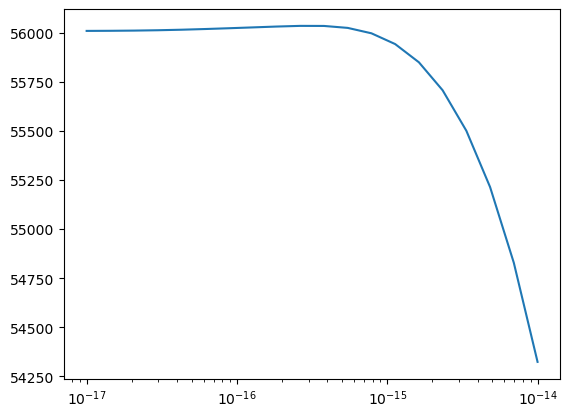

In [11]:
import matplotlib.pyplot as plt
plt.plot(xvals_h,yvals_h)
plt.xscale('log')

# likelihood curve for efac 

In [29]:

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax.scipy.linalg import block_diag
from jax import random


import pandas as pd
import numpy as np 
from flax import struct
from datetime import datetime


from argus import models
from argus import jax_kalman_filter


#NumPyro
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC,SA,NUTS


#Arviz
import arviz as az


@struct.dataclass
class Parameters:

    """Define a struct to store the parameters of the Kalman filter model"""
    
    #GW parameters
    γa: float  # s⁻¹
    ha: float  # GWB amplitude

    #Pulsar parameters for the OU process
    γp: jnp.ndarray  # Pulsar-specific gamma values
    σp: jnp.ndarray  # Pulsar-specific sigma values 

    #Measurement noise parameters
    EFAC: jnp.ndarray  # Error factors
    EQUAD: jnp.ndarray # Extra quadrature noise




def get_likelihood_curve_efac():

    #Get the data
    data_path = "../data/IPTA_MockDataChallenge2/dataset_2b/" 
    processed_pulsar_residuals, pulsar_metadata, pulsar_design_matrices,P_eps_matrices,hd_correlation_matrix = _get_processed_residuals(data_path)

    #Get efac and equad
    efac_array, equad_array = get_efac_equad_injections()
    assert len(efac_array) == len(equad_array) == len(pulsar_metadata)

    #Get psr noise 
    sigma_p_injected, gamma_p_injected = get_psr_noise_injections()
    assert len(sigma_p_injected) == len(gamma_p_injected) == len(pulsar_metadata)


    #Calculate P0 based on the maximum value of the design matrix, and a delta tolerance
    model = models.StochasticGWBackgroundModel(pulsar_metadata, hd_correlation_matrix, pulsar_design_matrices)

    alpha = 1.0 #scale slightly 
    P0 = alpha*block_diag(*P_eps_matrices)


    KF = jax_kalman_filter.JaxKalmanFilter(
        model=model, 
        observations=processed_pulsar_residuals, 
        Peps=P0
    )




    γa = 1e-9 
    ha = 10**(-15.51)#1e-15

    #Set the parameters
    params = Parameters(
        #GW parameters
        γa=γa,
        ha=ha,

        #Spin parameters
        γp=gamma_p_injected,
        σp=sigma_p_injected,

        #Measurement noise parameters
        EFAC=efac_array,
        EQUAD=equad_array
    )

    print("First call to get_likelihood. Just for precompilation")
    ll = KF.get_likelihood(params) 
    ll.block_until_ready()
    print("Likelihood: ",ll)



    print("Starting the loop")

    psr_idx = 1
    xvals = np.linspace(0.1,10,150)
    yvals = np.zeros_like(xvals)

    print("The quoted efac is: ",efac_array[psr_idx])
    
    for i,s in enumerate(xvals):


        EFAC_modified_array = efac_array.at[psr_idx].set(s)
        #Set the parameters
        params = Parameters(
            #GW parameters
            γa=γa,
            ha=ha,

            #Spin parameters
            γp=gamma_p_injected,
            σp=sigma_p_injected,

            #Measurement noise parameters
            EFAC=EFAC_modified_array,
            EQUAD=equad_array
        )

 
        ll = KF.get_likelihood(params) 
        yvals[i] = ll

    return xvals, yvals






In [30]:
x_efac,y_efac = get_likelihood_curve_efac()

Getting the data. Loading 32 pulsars from ../data/IPTA_MockDataChallenge2/dataset_2b/
[preProcess.C:158] Warning: PSR J0030+0451 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0030+0451, F0: 205.53069593846152, # TOAs: 183
[preProcess.C:158] Warning: PSR J0034-0534 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0034-0534, F0: 532.7134293952242, # TOAs: 183
[preProcess.C:158] Warning: PSR J0218+4232 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0218+4232, F0: 430.46105454575843, # TOAs: 183
[preProcess.C:158] Warning: PSR J0437-4715 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0437-4715, F0: 173.6879457375193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0613-0200 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0613-0200, F0: 326.60056202349193, # TOAs: 183
[preProcess.C:158] Warning: PSR J0621+1002 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0621+1002, F0: 34.65740662142043, # TOAs: 183
[preProcess.C:158] Warning: PSR J0711-6830 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0711-6830, F0: 182.1172346472276, # TOAs: 183
[preProcess.C:158] Warning: PSR J0751+1807 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J0751+1807, F0: 287.4578539950941, # TOAs: 183
[preProcess.C:158] Warning: PSR J0900-3144 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J0900-3144, F0: 90.0118419193632, # TOAs: 183
[preProcess.C:158] Warning: PSR J1012+5307 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1012+5307, F0: 190.26783444155498, # TOAs: 183
[preProcess.C:158] Warning: PSR J1022+1001 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1022+1001, F0: 60.779447956696714, # TOAs: 183
[preProcess.C:158] Warning: PSR J1024-0719 uses DM2+ but does not define DM_SERIES.

PSR: J1603-7202, F0: 67.37658112877924, # TOAs: 183
[preProcess.C:158] Warning: PSR J1614-2230 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1614-2230, F0: 317.37893706872126, # TOAs: 183
[preProcess.C:158] Warning: PSR J1643-1224 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1643-1224, F0: 216.37333714263485, # TOAs: 183
[preProcess.C:158] Warning: PSR J1713+0747 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J1713+0747, F0: 218.81184041715784, # TOAs: 183
[preProcess.C:158] Warning: PSR J1730-2304 uses DM2+ but does not define DM_SERIE

PSR: J1939+2134, F0: 641.9282245822469, # TOAs: 183
[preProcess.C:158] Warning: PSR J1944+0907 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor



PSR: J1944+0907, F0: 192.85651792018598, # TOAs: 183
[preProcess.C:158] Warning: PSR J2010-1323 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2010-1323, F0: 191.45090909263828, # TOAs: 183
[preProcess.C:158] Warning: PSR J2124-3358 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2124-3358, F0: 202.7938937460303, # TOAs: 183
[preProcess.C:158] Warning: PSR J2129-5721 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2129-5721, F0: 268.3592272938787, # TOAs: 183
[preProcess.C:158] Warning: PSR J2145-0750 uses DM2+ but does not define DM_SERIES

PSR: J2145-0750, F0: 62.29588783738885, # TOAs: 183
[preProcess.C:158] Warning: PSR J2229+2643 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2229+2643, F0: 335.81620819685526, # TOAs: 183
[preProcess.C:158] Warning: PSR J2317+1439 uses DM2+ but does not define DM_SERIES. Assume Taylor. This has behaviour has changed since June 2020!
See https://bitbucket.org/psrsoft/tempo2/issues/27/tempo2-dm-polynomial-is-not-a-taylor

PSR: J2317+1439, F0: 290.2546036648635, # TOAs: 183
The number of pulsars is: 32
The frequencies are: [205.53069594 532.7134294  430.46105455 173.68794574 326.60056202
  34.65740662 182.11723465 287.457854    90.01184192 190.26783444
  60.77944796 193.71568345 133.79314954 125.20024324 277.93770699
  67.37658113 317.37893707 216.37333714 218.81184042 123.11028715
 245.42611969 186.49407838 339.31568722 130.78951412 641.

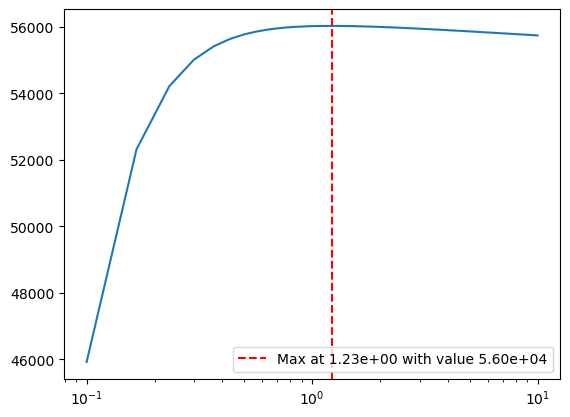

In [31]:

plt.plot(x_efac, y_efac)
max_idx = np.argmax(y_efac)
max_y = y_efac[max_idx]
plt.axvline(x=x_efac[max_idx], color='r', linestyle='--', label=f'Max at {x_efac[max_idx]:.2e} with value {max_y:.2e}')
plt.legend()
plt.xscale('log')